# LangGraph Subgraphs

This notebook demonstrates two practical ways to use a subgraph inside a parent graph. The first example shares one state schema. The second example uses a separate subgraph state and runs one subgraph per topic with `Send`.


## Architecture Overview

| Example | Integration style | State relationship | Main purpose |
|---|---|---|---|
| Order Processing | Add the compiled subgraph directly as a parent node | Parent and subgraph share `OrderState` | Group related order-processing steps |
| Parallel Research | Invoke the subgraph inside a worker | Parent, worker, and subgraph use different state schemas | Reuse one subgraph for dynamically created tasks |

```text
Example 1
START → validate_request → [check_inventory → calculate_price] → final_response → END

Example 2
                              ┌→ worker(topic 1) → research subgraph ─┐
START → prepare_topics → Send ├→ worker(topic 2) → research subgraph ─┼→ combine_results → END
                              └→ worker(topic 3) → research subgraph ─┘
```


In [20]:
from typing import Annotated, TypedDict
import operator

from langgraph.graph import StateGraph, START, END
from langgraph.types import Send


In [21]:
def show_graph(compiled_graph, *, xray=False):
    """Print the generated graph as Mermaid text."""

    print(
        compiled_graph.get_graph(
            xray=xray
        ).draw_mermaid()
    )


## 1. Shared-State Order Subgraph

### What it does

The parent graph validates an order. A nested subgraph checks inventory and calculates the price. The parent then creates the final response.

### Why it is a subgraph

`order_subgraph` is compiled separately and added to the parent as the `order_processing` node. Because both graphs use `OrderState`, state values pass between them automatically.

### Simple real-world example

An online store receives an order, checks whether enough items are available, calculates the total, and then confirms or rejects the order.


In [22]:
class OrderState(TypedDict):
    product: str
    quantity: int
    inventory_status: str
    total_price: float
    final_response: str

In [23]:
PRODUCT_CATALOG = {
    "Keyboard": {"stock": 5, "unit_price": 500.0},
    "Mouse": {"stock": 10, "unit_price": 250.0},
}

### 1.1 Subgraph nodes

`check_inventory` updates availability. `calculate_price` uses the selected product and requested quantity.


In [24]:
def check_inventory(state: OrderState):
    print("Checking inventory...")

    product = PRODUCT_CATALOG[state["product"]]
    is_available = product["stock"] >= state["quantity"]

    return {
        "inventory_status": (
            "Available" if is_available else "Unavailable"
        )
    }


def calculate_price(state: OrderState):
    print("Calculating price...")

    if state["inventory_status"] != "Available":
        return {"total_price": 0.0}

    unit_price = PRODUCT_CATALOG[state["product"]]["unit_price"]

    return {
        "total_price": state["quantity"] * unit_price
    }


### 1.2 Build the order subgraph


In [25]:
order_subgraph_builder = StateGraph(OrderState)

order_subgraph_builder.add_node(
    "check_inventory",
    check_inventory,
)

order_subgraph_builder.add_node(
    "calculate_price",
    calculate_price,
)

order_subgraph_builder.add_edge(
    START,
    "check_inventory",
)

order_subgraph_builder.add_edge(
    "check_inventory",
    "calculate_price",
)

order_subgraph_builder.add_edge(
    "calculate_price",
    END,
)

order_subgraph = order_subgraph_builder.compile()


### 1.3 Parent graph nodes


In [26]:
def validate_request(state: OrderState):
    print("Validating request...")

    if state["product"] not in PRODUCT_CATALOG:
        raise ValueError(f"Unknown product: {state['product']}")

    if state["quantity"] <= 0:
        raise ValueError("Quantity must be greater than zero.")

    return {}


def create_final_response(state: OrderState):
    if state["inventory_status"] == "Available":
        response = (
            f"{state['quantity']} {state['product']} ordered. "
            f"Total Price: ₹{state['total_price']:,.2f}"
        )
    else:
        response = (
            f"Order not placed. {state['quantity']} "
            f"{state['product']} are not available."
        )

    return {
        "final_response": response
    }


### 1.4 Build the parent graph


In [27]:
order_builder = StateGraph(OrderState)

order_builder.add_node(
    "validate_request",
    validate_request,
)

# The complete compiled subgraph becomes one parent node.
order_builder.add_node(
    "order_processing",
    order_subgraph,
)

order_builder.add_node(
    "final_response",
    create_final_response,
)

order_builder.add_edge(
    START,
    "validate_request",
)

order_builder.add_edge(
    "validate_request",
    "order_processing",
)

order_builder.add_edge(
    "order_processing",
    "final_response",
)

order_builder.add_edge(
    "final_response",
    END,
)

order_graph = order_builder.compile()


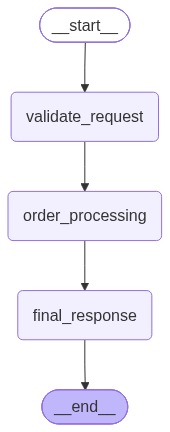

In [29]:
order_graph

### 1.5 Generated graph structure

`xray=True` expands the nested subgraph inside the parent graph. This cell does not make a model call.


In [28]:
show_graph(
    order_graph,
    xray=True,
)


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	validate_request(validate_request)
	final_response(final_response)
	__end__([<p>__end__</p>]):::last
	__start__ --> validate_request;
	order_processing\3acalculate_price --> final_response;
	validate_request --> order_processing\3acheck_inventory;
	final_response --> __end__;
	subgraph order_processing
	order_processing\3acheck_inventory(check_inventory)
	order_processing\3acalculate_price(calculate_price)
	order_processing\3acheck_inventory --> order_processing\3acalculate_price;
	end
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



### 1.6 Test the order workflow

**Model calls:** 0

**Expected behavior:** The request is validated, inventory is checked, the price is calculated, and the final confirmation shows ₹1,000.00.


In [31]:
def run_order_workflow():
    result = order_graph.invoke(
        {
            "product": "Keyboard",
            "quantity": 2,
        }
    )

    print(result["final_response"])

    return result


In [32]:
order_result = run_order_workflow()


Validating request...
Checking inventory...
Calculating price...
2 Keyboard ordered. Total Price: ₹1,000.00


**Common mistake:** A direct subgraph node works cleanly here because the parent and subgraph share the same state keys.

**Student exercise:** Change the quantity to `6` and confirm that the order is rejected because only five keyboards are available.


## 2. Parallel Research Subgraph with `Send`

### What it does

The parent graph creates one worker per topic. Each worker invokes the same research subgraph, and the parent combines all summaries.

### Why this integration is different

The parent uses `ParentState`, each worker receives `ResearchWorkerInput`, and the subgraph uses `ResearchState`. The worker acts as an adapter between these different schemas.

### Simple real-world example

A research coordinator assigns different topics to researchers. Every researcher follows the same research-and-summary process, and an instructor combines the completed summaries.


In [ ]:
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

load_dotenv()

model = ChatOpenAI(
    model="gpt-4.1-mini",
    temperature=0,
)

### 2.1 Parent, worker, and subgraph states


In [34]:
class ParentState(TypedDict):
    topics: list[str]
    research_results: Annotated[
        list[str],
        operator.add,
    ]
    final_answer: str


class ResearchWorkerInput(TypedDict):
    topic: str


class ResearchState(TypedDict):
    topic: str
    research: str
    summary: str


### 2.2 Research subgraph nodes


In [35]:
def research_topic(state: ResearchState):
    topic = state["topic"]
    print(f"[SUBGRAPH] Researching: {topic}")

    response = model.invoke(
        f"""
Explain this Generative AI topic: {topic}

Include:
1. A definition
2. Important concepts
3. One practical use case

Keep the explanation concise.
"""
    )

    return {
        "research": response.content
    }


def summarize_topic(state: ResearchState):
    print(f"[SUBGRAPH] Summarizing: {state['topic']}")

    response = model.invoke(
        f"""
Create a concise summary of this research.

Topic: {state['topic']}

Research:
{state['research']}
"""
    )

    return {
        "summary": response.content
    }


### 2.3 Build the research subgraph


In [36]:
research_builder = StateGraph(ResearchState)

research_builder.add_node(
    "research_topic",
    research_topic,
)

research_builder.add_node(
    "summarize_topic",
    summarize_topic,
)

research_builder.add_edge(
    START,
    "research_topic",
)

research_builder.add_edge(
    "research_topic",
    "summarize_topic",
)

research_builder.add_edge(
    "summarize_topic",
    END,
)

research_subgraph = research_builder.compile()


### 2.4 Parent graph nodes

`Send` creates one worker input per topic. The reducer on `research_results` safely combines worker outputs.


In [37]:
def prepare_topics(state: ParentState):
    print("Topics received:")

    for topic in state["topics"]:
        print(f"- {topic}")

    return {}


def research_worker(state: ResearchWorkerInput):
    topic = state["topic"]
    print(f"[WORKER] Starting: {topic}")

    subgraph_result = research_subgraph.invoke(
        {
            "topic": topic,
            "research": "",
            "summary": "",
        }
    )

    return {
        "research_results": [
            f"## {topic}\n\n{subgraph_result['summary']}"
        ]
    }


def distribute_topics(state: ParentState):
    return [
        Send(
            "research_worker",
            {"topic": topic},
        )
        for topic in state["topics"]
    ]


def combine_results(state: ParentState):
    combined_research = "\n\n".join(
        state["research_results"]
    )

    response = model.invoke(
        f"""
Combine these research summaries into one clear explanation.
Keep each topic under its own heading.

{combined_research}
"""
    )

    return {
        "final_answer": response.content
    }


### 2.5 Build the parent graph


In [38]:
research_parent_builder = StateGraph(ParentState)

research_parent_builder.add_node(
    "prepare_topics",
    prepare_topics,
)

research_parent_builder.add_node(
    "research_worker",
    research_worker,
)

research_parent_builder.add_node(
    "combine_results",
    combine_results,
)

research_parent_builder.add_edge(
    START,
    "prepare_topics",
)

research_parent_builder.add_conditional_edges(
    "prepare_topics",
    distribute_topics,
    ["research_worker"],
)

research_parent_builder.add_edge(
    "research_worker",
    "combine_results",
)

research_parent_builder.add_edge(
    "combine_results",
    END,
)

research_graph = research_parent_builder.compile()


### 2.6 Generated graph structures

The subgraph is invoked inside `research_worker`, so the parent diagram does not expand it automatically. Displaying both graphs makes the relationship clear.


In [39]:
print("RESEARCH SUBGRAPH")
show_graph(research_subgraph)

print("PARENT GRAPH")
show_graph(research_graph)


RESEARCH SUBGRAPH
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	research_topic(research_topic)
	summarize_topic(summarize_topic)
	__end__([<p>__end__</p>]):::last
	__start__ --> research_topic;
	research_topic --> summarize_topic;
	summarize_topic --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc

PARENT GRAPH
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	prepare_topics(prepare_topics)
	research_worker(research_worker)
	combine_results(combine_results)
	__end__([<p>__end__</p>]):::last
	__start__ --> prepare_topics;
	prepare_topics -.-> research_worker;
	research_worker --> combine_results;
	combine_results --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



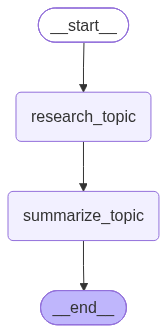

In [40]:
research_subgraph

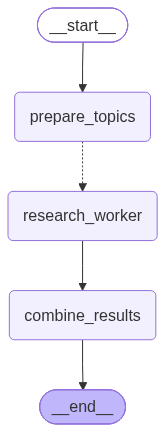

In [41]:
research_graph

### 2.7 Test the parallel research workflow

**Model calls:** 7 for the three-topic test: two calls per topic plus one final combination call.

**Expected behavior:** Three workers are created, each worker runs the two-node research subgraph, three results are collected, and one combined answer is printed. Worker log order may vary because the tasks can run in parallel.


In [42]:
def run_parallel_research_workflow():
    result = research_graph.invoke(
        {
            "topics": [
                "Retrieval-Augmented Generation",
                "AI Agents",
                "Memory Management",
            ],
            "research_results": [],
        }
    )

    print("\nFINAL ANSWER\n")
    print(result["final_answer"])

    return result


In [43]:
research_result = run_parallel_research_workflow()


Topics received:
- Retrieval-Augmented Generation
- AI Agents
- Memory Management
[WORKER] Starting: Retrieval-Augmented Generation
[SUBGRAPH] Researching: Retrieval-Augmented Generation
[WORKER] Starting: AI Agents
[SUBGRAPH] Researching: AI Agents
[WORKER] Starting: Memory Management
[SUBGRAPH] Researching: Memory Management
[SUBGRAPH] Summarizing: Retrieval-Augmented Generation
[SUBGRAPH] Summarizing: Memory Management
[SUBGRAPH] Summarizing: AI Agents

FINAL ANSWER

# Retrieval-Augmented Generation

Retrieval-Augmented Generation (RAG) is a generative AI technique that improves large language models by integrating external information retrieval. It combines a retriever component, which fetches relevant documents from a knowledge base, with a generator that produces informed and context-rich responses. Some RAG systems are trained end-to-end to jointly optimize both retrieval and generation. This approach is especially valuable in scenarios like customer support, where chatbots can 

**Common mistakes:** Removing the reducer from `research_results`, forgetting the `Send` destination list, or expecting the manually invoked subgraph to appear inside the parent diagram.

**Student exercise:** Add a fourth topic and confirm that LangGraph creates a fourth worker automatically.
